# 06 — Stress and Emotion Analysis

## Purpose

General sentiment and stress are related, but they are not the same.

- **Sentiment analysis** asks whether a text is positive, neutral, or negative.
- **Stress and emotion analysis** asks whether the text expresses stress,
  anxiety, frustration, exhaustion, fear, distrust, relief, or no clear
  emotional signal.

This notebook implements an **explainable rule-based baseline** for stress and
emotion detection.

It does not make clinical diagnoses.

## Main outputs

For every record, the notebook creates:

- `stress_direction`
- `stress_signal`
- `stress_intensity`
- `stress_intensity_score`
- `primary_emotion`
- `detected_emotions`
- `stress_causes`
- `stress_evidence`
- `stress_detection_confidence`

## Input priority

1. `data/results/sentiment/sentiment_predictions.jsonl`
2. `data/results/sentiment/vader_predictions.jsonl`
3. `data/processed/analysis_ready_posts.jsonl`

## Main output

`data/results/emotions/stress_emotion_predictions.jsonl`


## 1. Imports and paths

This phase uses only standard Python, pandas, NumPy, and matplotlib.


In [3]:
from pathlib import Path
import ast
import json
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")


def find_project_root(start=None):
    current = (start or Path.cwd()).resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data" / "processed").exists():
            return candidate

    raise FileNotFoundError(
        "Project root not found. Run this notebook from the project root "
        "or from the notebooks folder."
    )


PROJECT_ROOT = find_project_root()

SENTIMENT_PATH = (
    PROJECT_ROOT
    / "data"
    / "results"
    / "sentiment"
    / "sentiment_predictions.jsonl"
)

VADER_PATH = (
    PROJECT_ROOT
    / "data"
    / "results"
    / "sentiment"
    / "vader_predictions.jsonl"
)

ANALYSIS_READY_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "analysis_ready_posts.jsonl"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "data"
    / "results"
    / "emotions"
)

FIGURE_DIR = (
    PROJECT_ROOT
    / "figures"
    / "emotions"
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Emotion results:", RESULTS_DIR)
print("Emotion figures:", FIGURE_DIR)


Project root: /home/rei/Desktop/internship/AI-Developer-Sentiment
Emotion results: /home/rei/Desktop/internship/AI-Developer-Sentiment/data/results/emotions
Emotion figures: /home/rei/Desktop/internship/AI-Developer-Sentiment/figures/emotions


## 2. Load the best available dataset

The combined sentiment output is preferred because it contains both the
processed text and the sentiment predictions.


In [4]:
if SENTIMENT_PATH.exists():
    INPUT_PATH = SENTIMENT_PATH
    input_description = "Combined sentiment predictions"
elif VADER_PATH.exists():
    INPUT_PATH = VADER_PATH
    input_description = "VADER predictions"
elif ANALYSIS_READY_PATH.exists():
    INPUT_PATH = ANALYSIS_READY_PATH
    input_description = "Analysis-ready dataset"
else:
    raise FileNotFoundError(
        "No suitable input dataset was found. "
        "Run preprocessing and sentiment analysis first."
    )

df = pd.read_json(INPUT_PATH, lines=True)

print("Input type:", input_description)
print("Input file:", INPUT_PATH)
print(f"Loaded records: {len(df):,}")
print(f"Columns: {len(df.columns)}")

display(df.head(5))


Input type: Combined sentiment predictions
Input file: /home/rei/Desktop/internship/AI-Developer-Sentiment/data/results/sentiment/sentiment_predictions.jsonl
Loaded records: 2,666
Columns: 61


,record_id,source_id,source,platform,community,created_at_utc,date_known,is_recent_2025_plus,title_raw,body_raw,...,vader_compound,vader_label,transformer_token_count,transformer_was_truncated,transformer_negative,transformer_neutral,transformer_positive,transformer_label,transformer_confidence,methods_agree
0,huggingface_uit-sentiment-dataset-reddit-2000-...,1kby1en,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,LocalLLaMA,2025-05-01T02:22:03+00:00,True,True,,Shuttle-3.5 (Qwen3 32b Finetune) We are excite...,...,0.3400,Positive,62,False,0.001459,0.042333,0.956209,Positive,0.956209,True
1,huggingface_uit-sentiment-dataset-reddit-2000-...,1kbym1e,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,OpenAI,2025-05-01T02:52:48+00:00,True,True,,current llms still suck I am using the top mod...,...,-0.6597,Negative,79,False,0.927499,0.065074,0.007427,Negative,0.927499,True
2,huggingface_uit-sentiment-dataset-reddit-2000-...,1kchgyo,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,LocalLLaMA,2025-05-01T19:33:44+00:00,True,True,,Anthropic claims chips are smuggled as prosthe...,...,0.4767,Positive,55,False,0.722723,0.261337,0.015939,Negative,0.722723,False
3,huggingface_uit-sentiment-dataset-reddit-2000-...,1kd9kcf,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,singularity,2025-05-02T19:28:21+00:00,True,True,,"I don't know why but being called a ""Human"" by...",...,0.3919,Positive,26,False,0.429451,0.505828,0.064720,Neutral,0.505828,False
4,huggingface_uit-sentiment-dataset-reddit-2000-...,1kdqcjk,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,LocalLLaMA,2025-05-03T11:00:49+00:00,True,True,,Teaching LLMs to use tools with RL! Successful...,...,0.9858,Positive,373,False,0.004174,0.128352,0.867474,Positive,0.867474,True


## 3. Validate and normalize fields

The analysis requires:

- `record_id`
- `platform`
- `text_clean_basic`

Optional sentiment, date, tool, and theme columns are preserved.


In [5]:
required_columns = [
    "record_id",
    "platform",
    "text_clean_basic",
]

missing_required = [
    column for column in required_columns
    if column not in df.columns
]

if missing_required:
    raise ValueError(
        "Missing required columns: "
        + ", ".join(missing_required)
    )

df["text_clean_basic"] = (
    df["text_clean_basic"]
    .fillna("")
    .astype(str)
    .str.strip()
)

if df["record_id"].isna().any():
    raise ValueError("Some records have no record_id.")

if df["record_id"].duplicated().any():
    raise ValueError("Duplicate record_id values were found.")

if df["text_clean_basic"].eq("").any():
    raise ValueError("Some records have empty text_clean_basic values.")


def ensure_list(value):
    if isinstance(value, list):
        return value

    if value is None:
        return []

    try:
        if pd.isna(value):
            return []
    except (TypeError, ValueError):
        pass

    if isinstance(value, str):
        value = value.strip()

        if not value or value.lower() in {
            "nan", "none", "null", "[]"
        }:
            return []

        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return parsed
        except (ValueError, SyntaxError):
            pass

        return [value]

    return [value]


for column in ["ai_tools", "research_themes"]:
    if column in df.columns:
        df[column] = df[column].map(ensure_list)
    else:
        df[column] = [[] for _ in range(len(df))]

if "created_at_utc" in df.columns:
    df["created_at_utc"] = pd.to_datetime(
        df["created_at_utc"],
        errors="coerce",
        utc=True,
    )
else:
    df["created_at_utc"] = pd.NaT

if "transformer_label" in df.columns:
    df["selected_sentiment_label"] = df["transformer_label"]
    SENTIMENT_METHOD = "Transformer"
elif "vader_label" in df.columns:
    df["selected_sentiment_label"] = df["vader_label"]
    SENTIMENT_METHOD = "VADER"
else:
    df["selected_sentiment_label"] = "Unknown"
    SENTIMENT_METHOD = "Unavailable"

print("Selected sentiment method:", SENTIMENT_METHOD)
print("Normalization completed.")


Selected sentiment method: Transformer
Normalization completed.


## 4. Define the emotion lexicons

The categories are based on explicit linguistic signals.

They are not inferred from negative sentiment alone.


In [6]:
EMOTION_LEXICONS = {
    "Stress or anxiety": [
        "stress",
        "stressed",
        "stressful",
        "anxiety",
        "anxious",
        "overwhelmed",
        "overwhelming",
        "pressure",
        "under pressure",
        "worried",
        "worry",
        "worrying",
        "panic",
        "panicking",
        "nervous",
        "uneasy",
        "tense",
        "dread",
        "afraid",
        "scared",
        "fear",
    ],
    "Frustration": [
        "frustrated",
        "frustrating",
        "frustration",
        "annoyed",
        "annoying",
        "irritated",
        "irritating",
        "infuriating",
        "fed up",
        "sick of",
        "waste of time",
        "keeps failing",
        "does not work",
        "doesn't work",
        "broken",
        "stuck",
        "painful",
        "nightmare",
        "hate",
        "useless",
    ],
    "Burnout or exhaustion": [
        "burnout",
        "burned out",
        "burnt out",
        "exhausted",
        "exhausting",
        "drained",
        "tired",
        "fatigue",
        "fatigued",
        "overworked",
        "workload",
        "cannot keep up",
        "can't keep up",
        "mentally exhausted",
        "emotionally exhausted",
    ],
    "Job insecurity or fear": [
        "replace developers",
        "replace programmers",
        "replace software engineers",
        "replace my job",
        "replace our jobs",
        "take my job",
        "take our jobs",
        "lose my job",
        "losing my job",
        "job loss",
        "job security",
        "job insecurity",
        "unemployment",
        "unemployed",
        "obsolete",
        "redundant",
        "layoff",
        "layoffs",
        "career threat",
        "threat to developers",
    ],
    "Distrust or uncertainty": [
        "cannot trust",
        "can't trust",
        "do not trust",
        "don't trust",
        "unreliable",
        "untrustworthy",
        "hallucination",
        "hallucinations",
        "hallucinate",
        "hallucinates",
        "inaccurate",
        "incorrect",
        "wrong answer",
        "wrong answers",
        "uncertain",
        "uncertainty",
        "unpredictable",
        "inconsistent",
        "doubt",
        "skeptical",
        "sceptical",
        "concern",
        "concerned",
        "risky",
        "risk",
    ],
    "Relief or reduced stress": [
        "less stressful",
        "reduces stress",
        "reduce stress",
        "reduced stress",
        "relieves stress",
        "relieve stress",
        "stress relief",
        "takes pressure off",
        "eases the pressure",
        "peace of mind",
        "feel relieved",
        "feeling relieved",
        "relief",
        "less anxious",
        "reduces anxiety",
        "reduced anxiety",
        "makes life easier",
        "easier to manage",
        "saves me time",
        "saves time",
        "helps me focus",
        "more confident",
    ],
}

INTENSIFIERS = [
    "extremely",
    "very",
    "really",
    "constantly",
    "always",
    "completely",
    "totally",
    "deeply",
    "terrified",
    "severely",
    "incredibly",
]

NEGATION_RELIEF_PATTERNS = [
    "not stressful",
    "no longer stressed",
    "no longer stressful",
    "not anxious",
    "less stressed",
    "less anxious",
    "without stress",
    "without anxiety",
]

print("Emotion categories:", list(EMOTION_LEXICONS))


Emotion categories: ['Stress or anxiety', 'Frustration', 'Burnout or exhaustion', 'Job insecurity or fear', 'Distrust or uncertainty', 'Relief or reduced stress']


## 5. Define likely stress causes

These categories describe what the emotion appears to be about.


In [7]:
CAUSE_LEXICONS = {
    "Job security and replacement": [
        "job",
        "career",
        "replace developers",
        "replace programmers",
        "layoff",
        "unemployment",
        "obsolete",
        "redundant",
    ],
    "Code quality and debugging": [
        "bug",
        "bugs",
        "debug",
        "debugging",
        "broken code",
        "code quality",
        "error",
        "errors",
        "failing test",
        "tests fail",
        "compile",
        "compilation",
        "incorrect code",
    ],
    "Reliability and hallucinations": [
        "hallucination",
        "hallucinations",
        "hallucinate",
        "unreliable",
        "inaccurate",
        "incorrect",
        "wrong answer",
        "cannot trust",
        "can't trust",
        "inconsistent",
    ],
    "Workload and productivity": [
        "workload",
        "deadline",
        "deadlines",
        "productivity",
        "productive",
        "time pressure",
        "save time",
        "saves time",
        "faster",
        "slower",
        "work faster",
        "keep up",
    ],
    "Privacy and security": [
        "privacy",
        "private data",
        "personal data",
        "security",
        "secure",
        "data leak",
        "leak",
        "confidential",
        "surveillance",
    ],
    "Cost and access": [
        "price",
        "pricing",
        "cost",
        "expensive",
        "subscription",
        "paywall",
        "rate limit",
        "usage limit",
        "access",
    ],
    "Learning and skill pressure": [
        "learning",
        "learn",
        "skill",
        "skills",
        "upskill",
        "reskill",
        "beginner",
        "junior developer",
        "keep learning",
        "fall behind",
    ],
    "General AI uncertainty": [
        "future of ai",
        "future of programming",
        "uncertain",
        "uncertainty",
        "rapid change",
        "changing fast",
        "ai agents",
        "automation",
    ],
}

THEME_TO_CAUSE = {
    "job_security": "Job security and replacement",
    "trust_quality": "Reliability and hallucinations",
    "productivity": "Workload and productivity",
    "privacy_security": "Privacy and security",
    "stress_anxiety": "General AI uncertainty",
    "burnout": "Workload and productivity",
}

print("Cause categories:", list(CAUSE_LEXICONS))


Cause categories: ['Job security and replacement', 'Code quality and debugging', 'Reliability and hallucinations', 'Workload and productivity', 'Privacy and security', 'Cost and access', 'Learning and skill pressure', 'General AI uncertainty']


## 6. Compile safe phrase patterns

Word boundaries prevent false matches inside unrelated words.


In [8]:
def compile_phrase(phrase):
    escaped = re.escape(phrase.lower())
    return re.compile(
        rf"(?<!\w){escaped}(?!\w)",
        flags=re.IGNORECASE,
    )


COMPILED_EMOTIONS = {
    category: [
        (phrase, compile_phrase(phrase))
        for phrase in phrases
    ]
    for category, phrases in EMOTION_LEXICONS.items()
}

COMPILED_CAUSES = {
    category: [
        (phrase, compile_phrase(phrase))
        for phrase in phrases
    ]
    for category, phrases in CAUSE_LEXICONS.items()
}

COMPILED_INTENSIFIERS = [
    compile_phrase(phrase)
    for phrase in INTENSIFIERS
]

COMPILED_RELIEF_NEGATIONS = [
    (phrase, compile_phrase(phrase))
    for phrase in NEGATION_RELIEF_PATTERNS
]


def find_phrase_matches(text, compiled_items):
    matches = []

    for phrase, pattern in compiled_items:
        if pattern.search(text):
            matches.append(phrase)

    return matches


print("Patterns compiled successfully.")


Patterns compiled successfully.


## 7. Stress and emotion detection function

Important rule:

> Negative sentiment by itself is not treated as stress.

At least one explicit stress- or emotion-related linguistic signal is required.


In [9]:
NEGATIVE_EMOTION_CATEGORIES = [
    "Stress or anxiety",
    "Frustration",
    "Burnout or exhaustion",
    "Job insecurity or fear",
    "Distrust or uncertainty",
]

RELIEF_CATEGORY = "Relief or reduced stress"


def analyze_stress_emotion(row):
    text = str(row["text_clean_basic"]).lower()

    emotion_matches = {
        category: find_phrase_matches(
            text,
            compiled_items,
        )
        for category, compiled_items
        in COMPILED_EMOTIONS.items()
    }

    # Explicit negated/reduced stress expressions count as relief.
    relief_negation_matches = find_phrase_matches(
        text,
        COMPILED_RELIEF_NEGATIONS,
    )

    if relief_negation_matches:
        emotion_matches[RELIEF_CATEGORY] = sorted(
            set(
                emotion_matches[RELIEF_CATEGORY]
                + relief_negation_matches
            )
        )

    emotion_counts = {
        category: len(matches)
        for category, matches in emotion_matches.items()
    }

    negative_hits = sum(
        emotion_counts[category]
        for category in NEGATIVE_EMOTION_CATEGORIES
    )

    relief_hits = emotion_counts[RELIEF_CATEGORY]

    intensifier_hits = sum(
        bool(pattern.search(text))
        for pattern in COMPILED_INTENSIFIERS
    )

    if negative_hits > 0 and relief_hits > 0:
        stress_direction = "Mixed or ambiguous"
        stress_signal = True
    elif negative_hits > 0:
        stress_direction = "Increased stress or distress"
        stress_signal = True
    elif relief_hits > 0:
        stress_direction = "Reduced stress or relief"
        stress_signal = False
    else:
        stress_direction = "No clear stress signal"
        stress_signal = False

    raw_intensity = negative_hits + min(
        intensifier_hits,
        2,
    )

    if negative_hits == 0:
        intensity_score = 0
        intensity_label = "None"
    elif raw_intensity == 1:
        intensity_score = 1
        intensity_label = "Low"
    elif raw_intensity <= 3:
        intensity_score = 2
        intensity_label = "Moderate"
    else:
        intensity_score = 3
        intensity_label = "High"

    detected_emotions = [
        category
        for category, count in emotion_counts.items()
        if count > 0
    ]

    if not detected_emotions:
        primary_emotion = "No clear emotion"
    elif (
        relief_hits > 0
        and negative_hits == 0
    ):
        primary_emotion = RELIEF_CATEGORY
    else:
        candidate_categories = (
            NEGATIVE_EMOTION_CATEGORIES
            + [RELIEF_CATEGORY]
        )

        primary_emotion = max(
            candidate_categories,
            key=lambda category: (
                emotion_counts[category],
                -candidate_categories.index(category),
            ),
        )

    cause_matches = {
        category: find_phrase_matches(
            text,
            compiled_items,
        )
        for category, compiled_items
        in COMPILED_CAUSES.items()
    }

    detected_causes = [
        category
        for category, matches in cause_matches.items()
        if matches
    ]

    for theme in row.get(
        "research_themes",
        [],
    ):
        mapped_cause = THEME_TO_CAUSE.get(
            str(theme),
        )

        if (
            mapped_cause
            and mapped_cause not in detected_causes
        ):
            detected_causes.append(mapped_cause)

    evidence = []

    for category, matches in emotion_matches.items():
        for phrase in matches:
            evidence.append(
                f"{category}: {phrase}"
            )

    if negative_hits >= 2 or raw_intensity >= 3:
        confidence = "High"
    elif negative_hits == 1 or relief_hits >= 1:
        confidence = "Moderate"
    else:
        confidence = "Low"

    return pd.Series({
        "stress_direction": stress_direction,
        "stress_signal": stress_signal,
        "stress_intensity": intensity_label,
        "stress_intensity_score": intensity_score,
        "primary_emotion": primary_emotion,
        "detected_emotions": detected_emotions,
        "stress_causes": detected_causes,
        "stress_evidence": evidence,
        "stress_detection_confidence": confidence,
        "negative_emotion_hit_count": negative_hits,
        "relief_hit_count": relief_hits,
    })


## 8. Apply the analysis to every record


In [10]:
emotion_results = df.apply(
    analyze_stress_emotion,
    axis=1,
)

df = pd.concat(
    [
        df.reset_index(drop=True),
        emotion_results.reset_index(drop=True),
    ],
    axis=1,
)

display(
    df[
        [
            "text_clean_basic",
            "selected_sentiment_label",
            "stress_direction",
            "stress_intensity",
            "primary_emotion",
            "stress_causes",
            "stress_evidence",
        ]
    ].head(15)
)


,text_clean_basic,selected_sentiment_label,stress_direction,stress_intensity,primary_emotion,stress_causes,stress_evidence
0,Shuttle-3.5 (Qwen3 32b Finetune) We are excite...,Positive,No clear stress signal,None,No clear emotion,[],[]
1,current llms still suck I am using the top mod...,Negative,No clear stress signal,None,No clear emotion,[],[]
2,Anthropic claims chips are smuggled as prosthe...,Negative,No clear stress signal,None,No clear emotion,[],[]
3,"I don't know why but being called a ""Human"" by...",Neutral,No clear stress signal,None,No clear emotion,[],[]
4,Teaching LLMs to use tools with RL! Successful...,Positive,No clear stress signal,None,No clear emotion,"[Cost and access, Learning and skill pressure,...",[]
5,Qwen3-235B-A22B (no thinking) Seemingly Outper...,Positive,No clear stress signal,None,No clear emotion,[],[]
6,CLAUDE MAX or Augmentcode? Hi guys I want to m...,Positive,No clear stress signal,None,No clear emotion,[Cost and access],[]
7,QwQ 32b vs Qwen 3 32b vs GLM-4-32B - HTML codi...,Neutral,No clear stress signal,None,No clear emotion,[],[]
8,"MCP Task Scheduler - Schedule Reminders, API c...",Neutral,No clear stress signal,None,No clear emotion,[],[]
9,This is how I’ll build AGI Hello community! I ...,Positive,No clear stress signal,None,No clear emotion,"[Cost and access, Learning and skill pressure]",[]


## 9. Validate outputs


In [11]:
valid_directions = [
    "Increased stress or distress",
    "Reduced stress or relief",
    "Mixed or ambiguous",
    "No clear stress signal",
]

valid_intensities = [
    "None",
    "Low",
    "Moderate",
    "High",
]

validation = {
    "records": len(df),
    "missing_stress_direction": int(
        df["stress_direction"].isna().sum()
    ),
    "invalid_stress_direction": int(
        (~df["stress_direction"].isin(
            valid_directions
        )).sum()
    ),
    "missing_primary_emotion": int(
        df["primary_emotion"].isna().sum()
    ),
    "invalid_stress_intensity": int(
        (~df["stress_intensity"].isin(
            valid_intensities
        )).sum()
    ),
    "records_with_explicit_stress_signal": int(
        df["stress_signal"].sum()
    ),
    "records_with_relief_signal": int(
        df["stress_direction"]
        .eq("Reduced stress or relief")
        .sum()
    ),
}

validation_table = (
    pd.Series(validation, name="value")
    .rename_axis("check")
    .reset_index()
)

display(validation_table)

validation_table.to_csv(
    RESULTS_DIR / "stress_emotion_validation.csv",
    index=False,
)


,check,value
0,records,2666
1,missing_stress_direction,0
2,invalid_stress_direction,0
3,missing_primary_emotion,0
4,invalid_stress_intensity,0
5,records_with_explicit_stress_signal,412
6,records_with_relief_signal,3


## 10. Overall stress-direction distribution


,stress_direction,records,percentage
0,Increased stress or distress,411,15.42
1,Mixed or ambiguous,1,0.04
2,Reduced stress or relief,3,0.11
3,No clear stress signal,2251,84.43


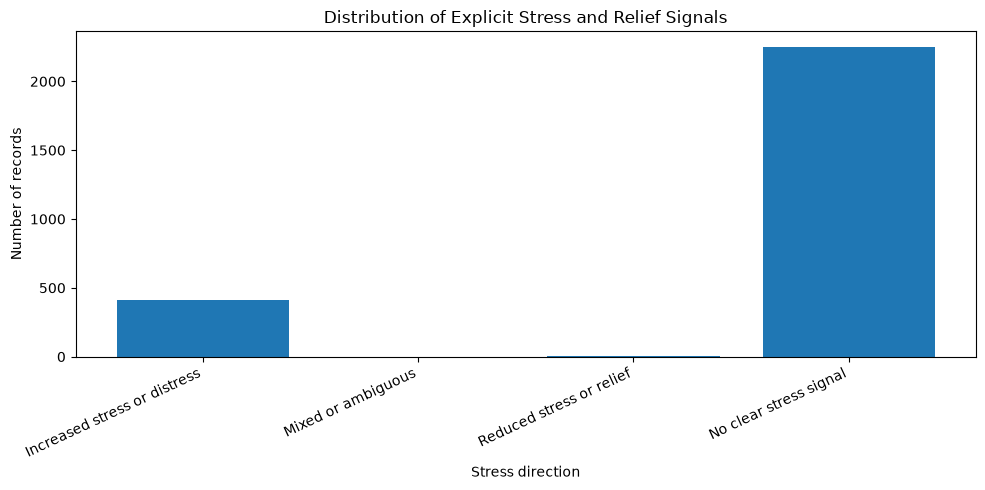

In [12]:
direction_order = [
    "Increased stress or distress",
    "Mixed or ambiguous",
    "Reduced stress or relief",
    "No clear stress signal",
]

stress_distribution = (
    df["stress_direction"]
    .value_counts()
    .reindex(direction_order, fill_value=0)
    .rename_axis("stress_direction")
    .reset_index(name="records")
)

stress_distribution["percentage"] = (
    stress_distribution["records"]
    / len(df)
    * 100
).round(2)

display(stress_distribution)

stress_distribution.to_csv(
    RESULTS_DIR / "stress_direction_distribution.csv",
    index=False,
)

plt.figure(figsize=(10, 5))

plt.bar(
    stress_distribution["stress_direction"],
    stress_distribution["records"],
)

plt.title("Distribution of Explicit Stress and Relief Signals")
plt.xlabel("Stress direction")
plt.ylabel("Number of records")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "stress_direction_distribution.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 11. Primary-emotion distribution


,primary_emotion,records,percentage
0,No clear emotion,2251,84.43
1,Frustration,153,5.74
2,Distrust or uncertainty,123,4.61
3,Stress or anxiety,102,3.83
4,Burnout or exhaustion,21,0.79
5,Job insecurity or fear,13,0.49
6,Relief or reduced stress,3,0.11


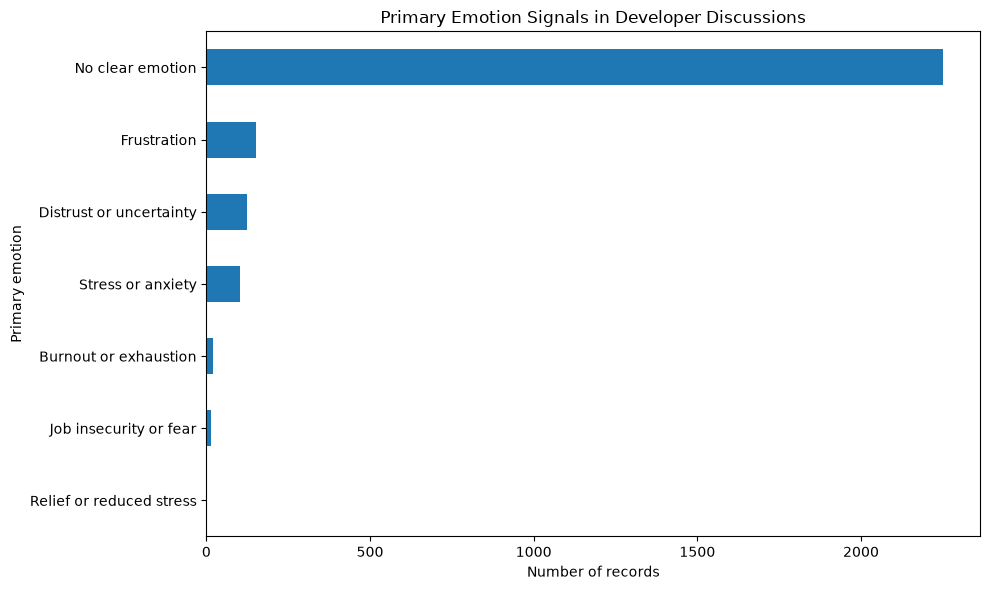

In [13]:
primary_emotion_distribution = (
    df["primary_emotion"]
    .value_counts()
    .rename_axis("primary_emotion")
    .reset_index(name="records")
)

primary_emotion_distribution["percentage"] = (
    primary_emotion_distribution["records"]
    / len(df)
    * 100
).round(2)

display(primary_emotion_distribution)

primary_emotion_distribution.to_csv(
    RESULTS_DIR / "primary_emotion_distribution.csv",
    index=False,
)

plot_data = (
    primary_emotion_distribution
    .sort_values("records")
    .set_index("primary_emotion")["records"]
)

plt.figure(figsize=(10, 6))

plot_data.plot(kind="barh")

plt.title("Primary Emotion Signals in Developer Discussions")
plt.xlabel("Number of records")
plt.ylabel("Primary emotion")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "primary_emotion_distribution.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 12. Stress intensity


,stress_intensity,records,percentage
0,None,2254,84.55
1,Low,196,7.35
2,Moderate,172,6.45
3,High,44,1.65


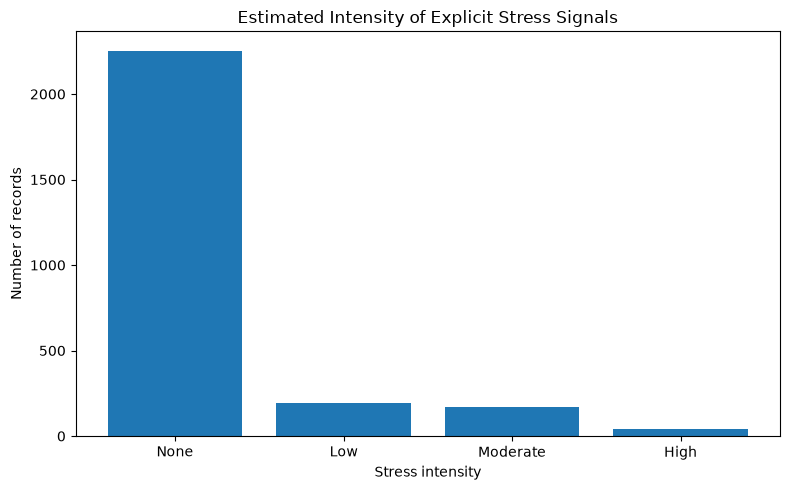

In [14]:
intensity_order = [
    "None",
    "Low",
    "Moderate",
    "High",
]

intensity_distribution = (
    df["stress_intensity"]
    .value_counts()
    .reindex(intensity_order, fill_value=0)
    .rename_axis("stress_intensity")
    .reset_index(name="records")
)

intensity_distribution["percentage"] = (
    intensity_distribution["records"]
    / len(df)
    * 100
).round(2)

display(intensity_distribution)

intensity_distribution.to_csv(
    RESULTS_DIR / "stress_intensity_distribution.csv",
    index=False,
)

plt.figure(figsize=(8, 5))

plt.bar(
    intensity_distribution["stress_intensity"],
    intensity_distribution["records"],
)

plt.title("Estimated Intensity of Explicit Stress Signals")
plt.xlabel("Stress intensity")
plt.ylabel("Number of records")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "stress_intensity_distribution.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 13. Stress direction by platform

Percentages are calculated within each platform.


stress_direction,Increased stress or distress,Mixed or ambiguous,Reduced stress or relief,No clear stress signal
platform,,,,
GitHub Issues,47,0,0,198
Hacker News,9,0,1,130
Other social dataset,7,0,0,132
Reddit,333,1,2,1697
Stack Overflow,15,0,0,94


stress_direction,Increased stress or distress,Mixed or ambiguous,Reduced stress or relief,No clear stress signal
platform,,,,
GitHub Issues,19.18,0.00,0.00,80.82
Hacker News,6.43,0.00,0.71,92.86
Other social dataset,5.04,0.00,0.00,94.96
Reddit,16.38,0.05,0.10,83.47
Stack Overflow,13.76,0.00,0.00,86.24


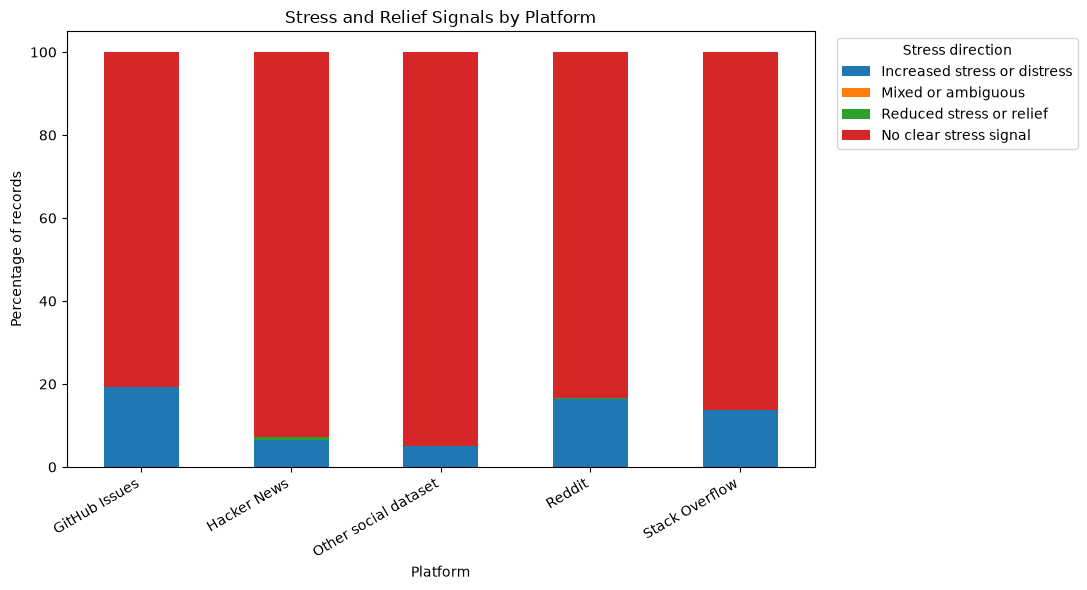

In [15]:
stress_by_platform_counts = (
    df.groupby(
        ["platform", "stress_direction"]
    )
    .size()
    .unstack(fill_value=0)
    .reindex(
        columns=direction_order,
        fill_value=0,
    )
)

platform_totals = (
    stress_by_platform_counts
    .sum(axis=1)
    .replace(0, np.nan)
)

stress_by_platform_percent = (
    stress_by_platform_counts
    .div(platform_totals, axis=0)
    .mul(100)
    .fillna(0)
    .round(2)
)

display(stress_by_platform_counts)
display(stress_by_platform_percent)

stress_by_platform_counts.to_csv(
    RESULTS_DIR / "stress_by_platform_counts.csv"
)

stress_by_platform_percent.to_csv(
    RESULTS_DIR / "stress_by_platform_percent.csv"
)

plt.figure(figsize=(11, 6))

stress_by_platform_percent.plot(
    kind="bar",
    stacked=True,
    ax=plt.gca(),
)

plt.title("Stress and Relief Signals by Platform")
plt.xlabel("Platform")
plt.ylabel("Percentage of records")
plt.xticks(rotation=30, ha="right")
plt.legend(
    title="Stress direction",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "stress_by_platform.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 14. Detected causes of stress and emotion


,stress_cause,records,percentage_of_all_records
0,Reliability and hallucinations,451,16.92
1,Code quality and debugging,350,13.13
2,Cost and access,305,11.44
3,Learning and skill pressure,211,7.91
4,Workload and productivity,209,7.84
5,Job security and replacement,172,6.45
6,General AI uncertainty,167,6.26
7,Privacy and security,121,4.54


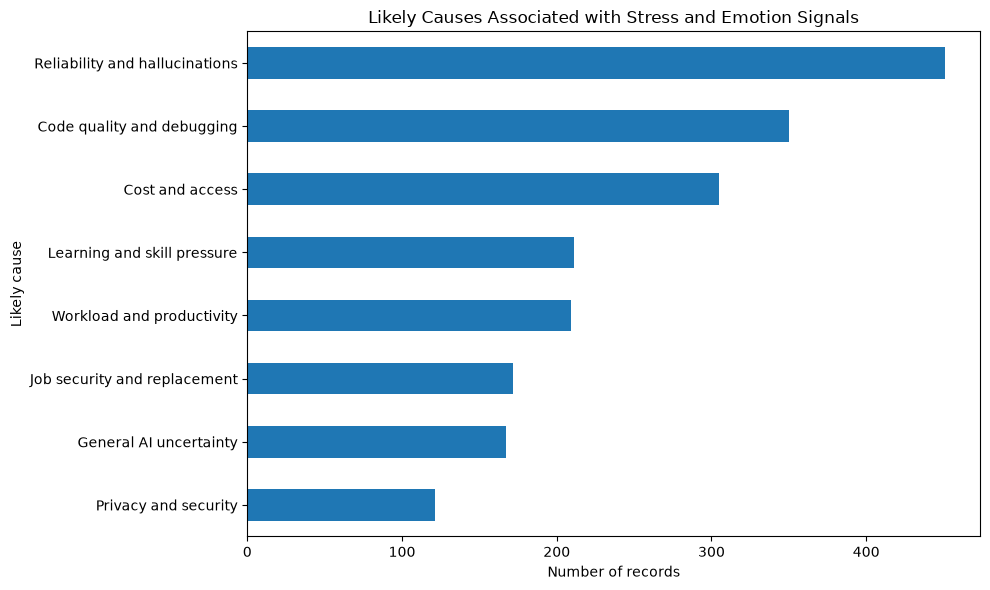

In [16]:
cause_data = (
    df[
        [
            "record_id",
            "stress_causes",
            "stress_direction",
        ]
    ]
    .explode("stress_causes")
    .reset_index(drop=True)
)

cause_data["stress_causes"] = (
    cause_data["stress_causes"]
    .replace("", np.nan)
)

cause_data = cause_data.dropna(
    subset=["stress_causes"]
)

cause_distribution = (
    cause_data["stress_causes"]
    .value_counts()
    .rename_axis("stress_cause")
    .reset_index(name="records")
)

cause_distribution["percentage_of_all_records"] = (
    cause_distribution["records"]
    / len(df)
    * 100
).round(2)

display(cause_distribution)

cause_distribution.to_csv(
    RESULTS_DIR / "stress_cause_distribution.csv",
    index=False,
)

if not cause_distribution.empty:
    plot_data = (
        cause_distribution
        .sort_values("records")
        .set_index("stress_cause")["records"]
    )

    plt.figure(figsize=(10, 6))

    plot_data.plot(kind="barh")

    plt.title("Likely Causes Associated with Stress and Emotion Signals")
    plt.xlabel("Number of records")
    plt.ylabel("Likely cause")
    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / "stress_cause_distribution.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


## 15. Sentiment versus stress

This table demonstrates that negative sentiment and stress are not identical.


In [17]:
sentiment_stress_table = pd.crosstab(
    df["selected_sentiment_label"],
    df["stress_direction"],
)

sentiment_stress_percent = pd.crosstab(
    df["selected_sentiment_label"],
    df["stress_direction"],
    normalize="index",
) * 100

sentiment_stress_percent = (
    sentiment_stress_percent
    .round(2)
)

display(sentiment_stress_table)
display(sentiment_stress_percent)

sentiment_stress_table.to_csv(
    RESULTS_DIR / "sentiment_vs_stress_counts.csv"
)

sentiment_stress_percent.to_csv(
    RESULTS_DIR / "sentiment_vs_stress_percent.csv"
)


stress_direction,Increased stress or distress,Mixed or ambiguous,No clear stress signal,Reduced stress or relief
selected_sentiment_label,,,,
Negative,128,0,354,0
Neutral,240,1,1464,2
Positive,43,0,433,1


stress_direction,Increased stress or distress,Mixed or ambiguous,No clear stress signal,Reduced stress or relief
selected_sentiment_label,,,,
Negative,26.56,0.00,73.44,0.00
Neutral,14.06,0.06,85.76,0.12
Positive,9.01,0.00,90.78,0.21


## 16. Stress signals by AI tool

A record may mention several tools and can therefore appear in several groups.


stress_direction,Increased stress or distress,Mixed or ambiguous,Reduced stress or relief,No clear stress signal
ai_tools,,,,
AI,203,1,1,858
Claude/Anthropic,95,0,1,565
Gemini,71,1,1,422
LLM,93,0,0,356
Llama,61,0,0,358
OpenAI,47,0,0,208
ChatGPT,60,0,1,186
GPT,43,0,0,192
GitHub Copilot,23,0,0,132


stress_direction,Increased stress or distress,Mixed or ambiguous,Reduced stress or relief,No clear stress signal
ai_tools,,,,
AI,19.10,0.09,0.09,80.71
Claude/Anthropic,14.37,0.00,0.15,85.48
Gemini,14.34,0.20,0.20,85.25
LLM,20.71,0.00,0.00,79.29
Llama,14.56,0.00,0.00,85.44
OpenAI,18.43,0.00,0.00,81.57
ChatGPT,24.29,0.00,0.40,75.30
GPT,18.30,0.00,0.00,81.70
GitHub Copilot,14.84,0.00,0.00,85.16


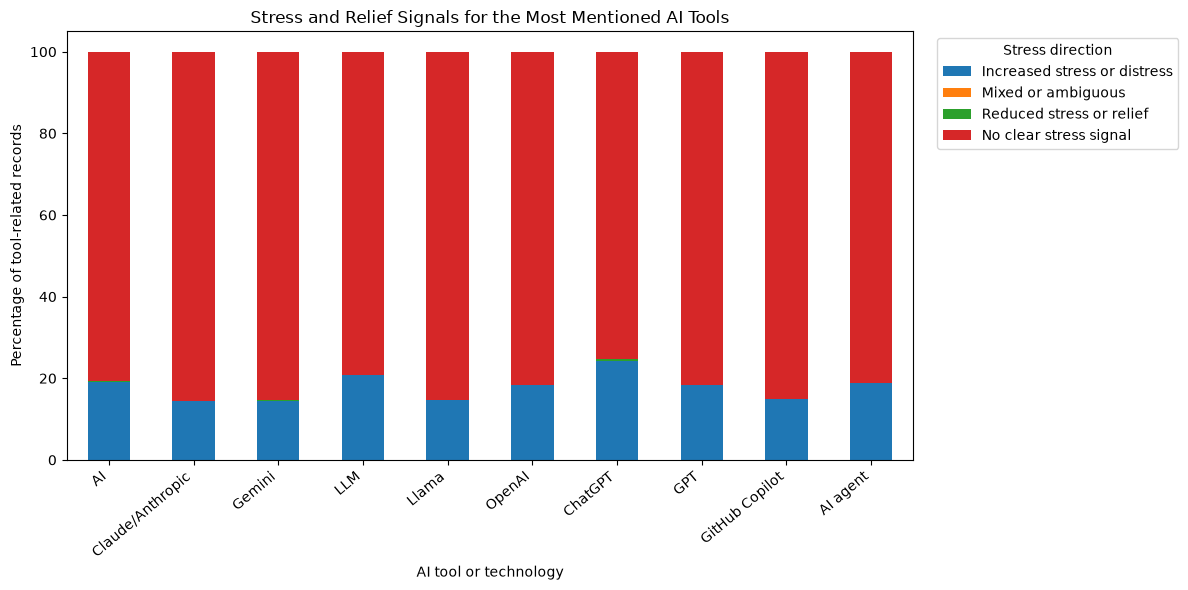

In [18]:
tool_stress_data = (
    df[
        [
            "record_id",
            "ai_tools",
            "stress_direction",
        ]
    ]
    .explode("ai_tools")
    .reset_index(drop=True)
)

tool_stress_data["ai_tools"] = (
    tool_stress_data["ai_tools"]
    .replace("", np.nan)
)

tool_stress_data = tool_stress_data.dropna(
    subset=["ai_tools"]
)

if tool_stress_data.empty:
    stress_by_tool_counts = pd.DataFrame()
    stress_by_tool_percent = pd.DataFrame()
    print("No AI-tool values are available.")
else:
    stress_by_tool_counts = (
        tool_stress_data
        .groupby(
            ["ai_tools", "stress_direction"]
        )
        .size()
        .unstack(fill_value=0)
        .reindex(
            columns=direction_order,
            fill_value=0,
        )
    )

    tool_totals = (
        stress_by_tool_counts
        .sum(axis=1)
        .replace(0, np.nan)
    )

    stress_by_tool_percent = (
        stress_by_tool_counts
        .div(tool_totals, axis=0)
        .mul(100)
        .fillna(0)
        .round(2)
    )

    stress_by_tool_counts.to_csv(
        RESULTS_DIR / "stress_by_ai_tool_counts.csv"
    )

    stress_by_tool_percent.to_csv(
        RESULTS_DIR / "stress_by_ai_tool_percent.csv"
    )

    top_tools = (
        stress_by_tool_counts
        .sum(axis=1)
        .sort_values(ascending=False)
        .head(10)
        .index
    )

    display(stress_by_tool_counts.loc[top_tools])
    display(stress_by_tool_percent.loc[top_tools])

    plt.figure(figsize=(12, 6))

    stress_by_tool_percent.loc[top_tools].plot(
        kind="bar",
        stacked=True,
        ax=plt.gca(),
    )

    plt.title("Stress and Relief Signals for the Most Mentioned AI Tools")
    plt.xlabel("AI tool or technology")
    plt.ylabel("Percentage of tool-related records")
    plt.xticks(rotation=40, ha="right")
    plt.legend(
        title="Stress direction",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )
    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / "stress_by_ai_tool.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


## 17. Stress signals over time

Only records with valid dates are used.


stress_direction,Increased stress or distress,Mixed or ambiguous,Reduced stress or relief,No clear stress signal
month,,,,
2025-08,13.88,0.0,0.24,85.89
2025-09,14.24,0.0,0.34,85.42
2025-10,14.62,0.0,0.00,85.38
2025-11,0.00,0.0,0.00,100.00
2025-12,16.67,0.0,0.00,83.33
2026-01,20.00,0.0,0.00,80.00
2026-02,20.00,0.0,0.00,80.00
2026-03,36.36,0.0,0.00,63.64
2026-04,11.11,0.0,0.00,88.89


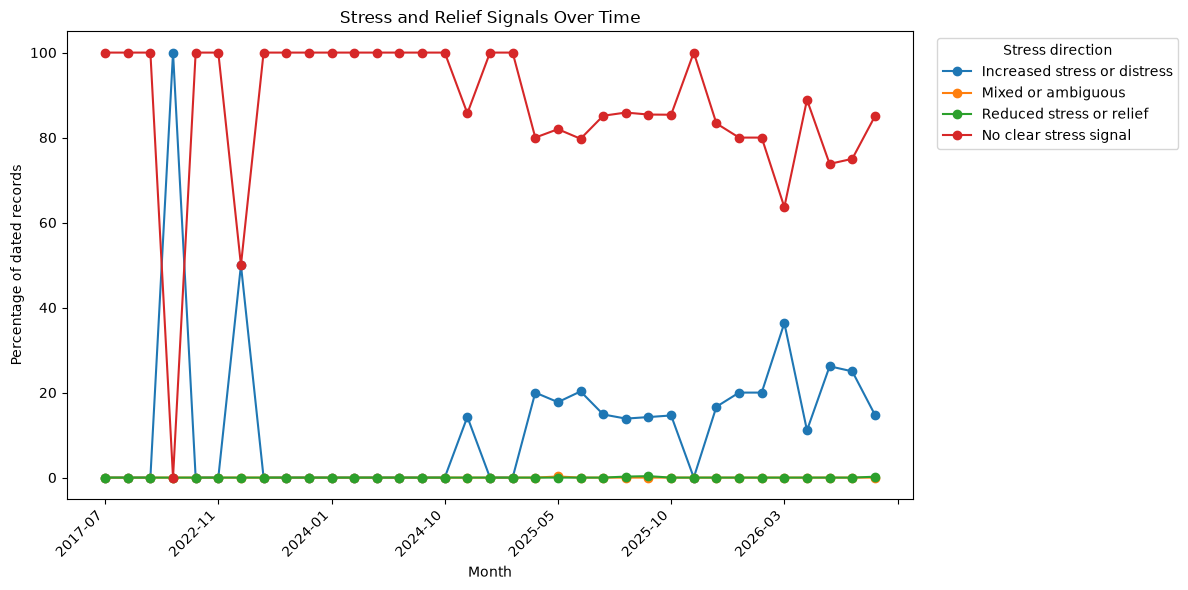

In [19]:
dated_df = (
    df.dropna(subset=["created_at_utc"])
    .copy()
)

if dated_df.empty:
    stress_over_time_counts = pd.DataFrame()
    stress_over_time_percent = pd.DataFrame()
    print("No dated records are available.")
else:
    dated_df["month"] = (
        dated_df["created_at_utc"]
        .dt.strftime("%Y-%m")
    )

    stress_over_time_counts = (
        dated_df
        .groupby(
            ["month", "stress_direction"]
        )
        .size()
        .unstack(fill_value=0)
        .reindex(
            columns=direction_order,
            fill_value=0,
        )
        .sort_index()
    )

    month_totals = (
        stress_over_time_counts
        .sum(axis=1)
        .replace(0, np.nan)
    )

    stress_over_time_percent = (
        stress_over_time_counts
        .div(month_totals, axis=0)
        .mul(100)
        .fillna(0)
        .round(2)
    )

    stress_over_time_counts.to_csv(
        RESULTS_DIR / "stress_over_time_counts.csv"
    )

    stress_over_time_percent.to_csv(
        RESULTS_DIR / "stress_over_time_percent.csv"
    )

    display(stress_over_time_percent.tail(12))

    plt.figure(figsize=(12, 6))

    stress_over_time_percent.plot(
        ax=plt.gca(),
        marker="o",
    )

    plt.title("Stress and Relief Signals Over Time")
    plt.xlabel("Month")
    plt.ylabel("Percentage of dated records")
    plt.xticks(rotation=45, ha="right")
    plt.legend(
        title="Stress direction",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )
    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / "stress_over_time.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


## 18. Inspect representative examples

Manual inspection remains necessary because rule-based analysis may produce
false positives or miss implicit emotions.


In [20]:
inspection_columns = [
    column for column in [
        "record_id",
        "platform",
        "text_clean_basic",
        "selected_sentiment_label",
        "stress_direction",
        "stress_intensity",
        "primary_emotion",
        "stress_causes",
        "stress_evidence",
        "stress_detection_confidence",
    ]
    if column in df.columns
]

for direction in direction_order:
    subset = df.loc[
        df["stress_direction"].eq(direction),
        inspection_columns,
    ]

    print(
        "\n",
        direction,
        "- records:",
        len(subset),
    )

    if not subset.empty:
        display(
            subset.sample(
                n=min(10, len(subset)),
                random_state=42,
            )
        )



 Increased stress or distress - records: 411


,record_id,platform,text_clean_basic,selected_sentiment_label,stress_direction,stress_intensity,primary_emotion,stress_causes,stress_evidence,stress_detection_confidence
1022,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Google Flow review I can't find a subreddit fo...,Neutral,Increased stress or distress,Moderate,Frustration,[Cost and access],[Frustration: useless],Moderate
173,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Anthropic’s AI utterly fails at running a busi...,Negative,Increased stress or distress,Low,Distrust or uncertainty,[],[Distrust or uncertainty: hallucinates],Moderate
458,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Why AI Wouldn't Just Wipe Out Humanity – A Tho...,Neutral,Increased stress or distress,High,Stress or anxiety,"[Workload and productivity, Cost and access, G...","[Stress or anxiety: stress, Stress or anxiety:...",High
2423,github_issues::4866712285,GitHub Issues,Cohere ASR chunk reassembly can crash on empty...,Neutral,Increased stress or distress,High,Burnout or exhaustion,"[Reliability and hallucinations, Workload and ...","[Burnout or exhaustion: workload, Distrust or ...",High
2455,github_issues::3734428965,GitHub Issues,Nodejs version 24.12.0 fails to compile module...,Neutral,Increased stress or distress,Low,Distrust or uncertainty,"[Code quality and debugging, Reliability and h...",[Distrust or uncertainty: incorrect],Moderate
512,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,"I increasingly feel that AGI is already here, ...",Negative,Increased stress or distress,High,Distrust or uncertainty,[Reliability and hallucinations],"[Distrust or uncertainty: hallucinations, Dist...",High
2614,arctic_shift::1v2q98j,Reddit,What's one tool your team adopted that actuall...,Positive,Increased stress or distress,Moderate,Frustration,[Workload and productivity],[Frustration: painful],Moderate
2653,stackoverflow::79616295,Stack Overflow,The code . command opens Cursor instead of VS ...,Neutral,Increased stress or distress,Low,Frustration,[Job security and replacement],[Frustration: annoying],Moderate
758,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,"'Sycophancy' and Emotional ""Intellect"" are 2 d...",Negative,Increased stress or distress,Moderate,Distrust or uncertainty,"[Privacy and security, Learning and skill pres...",[Distrust or uncertainty: concern],Moderate
2620,arctic_shift::1v2blw7,Reddit,"Built a free tool that turns ""it's broken"" int...",Neutral,Increased stress or distress,Low,Frustration,"[Code quality and debugging, Reliability and h...",[Frustration: broken],Moderate



 Mixed or ambiguous - records: 1


,record_id,platform,text_clean_basic,selected_sentiment_label,stress_direction,stress_intensity,primary_emotion,stress_causes,stress_evidence,stress_detection_confidence
925,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,AI's Top Use Case Is Probably Convincing News ...,Neutral,Mixed or ambiguous,Low,Stress or anxiety,"[Privacy and security, Cost and access]","[Stress or anxiety: pressure, Relief or reduce...",Moderate



 Reduced stress or relief - records: 3


,record_id,platform,text_clean_basic,selected_sentiment_label,stress_direction,stress_intensity,primary_emotion,stress_causes,stress_evidence,stress_detection_confidence
651,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,"3 Prompt Templates I Use Weekly (Mobile, Facel...",Neutral,Reduced stress or relief,None,Relief or reduced stress,[],[Relief or reduced stress: more confident],Moderate
1312,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Comet Browser. The automatic AI browser from P...,Positive,Reduced stress or relief,None,Relief or reduced stress,"[Workload and productivity, Cost and access]",[Relief or reduced stress: saves time],Moderate
2163,hackernews::48995181,Hacker News,Show HN: CodeAlmanac – Karpathy-style codebase...,Neutral,Reduced stress or relief,None,Relief or reduced stress,[],[Relief or reduced stress: relief],Moderate



 No clear stress signal - records: 2251


,record_id,platform,text_clean_basic,selected_sentiment_label,stress_direction,stress_intensity,primary_emotion,stress_causes,stress_evidence,stress_detection_confidence
1983,huggingface_divde-sentiment_posts::text-f9e3c0...,Other social dataset,Google is slipping behind on AI coding due to ...,Negative,No clear stress signal,None,No clear emotion,[],[],Low
2133,hackernews::48996382,Hacker News,Show HN: Tsaagan – Browser control for AI agen...,Neutral,No clear stress signal,None,No clear emotion,[General AI uncertainty],[],Low
700,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,"The Duality of ChatGPT 5 Ironic, ChatGPT 5 can...",Neutral,No clear stress signal,None,No clear emotion,[],[],Low
300,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,DeepSeek-V3.1 implements Anthropic API compati...,Neutral,No clear stress signal,None,No clear emotion,[],[],Low
2145,hackernews::48995907,Hacker News,Show HN: Autoretrieval – Autoresearch for RAG ...,Neutral,No clear stress signal,None,No clear emotion,[],[],Low
1052,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Gemini 2.5 Pro 06-05 Full Benchmark Table,Neutral,No clear stress signal,None,No clear emotion,[],[],Low
2216,github_issues::4913106929,GitHub Issues,Render Data Agent MCP Embedded Resource Querie...,Neutral,No clear stress signal,None,No clear emotion,[],[],Low
513,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,A conversation about AI for science and nation...,Neutral,No clear stress signal,None,No clear emotion,[Privacy and security],[],Low
2129,hackernews::48996573,Hacker News,OpenTakeoff – open-source construction takeoff...,Neutral,No clear stress signal,None,No clear emotion,[],[],Low
523,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,I made a chrome extension to export your ChatG...,Positive,No clear stress signal,None,No clear emotion,[],[],Low


## 19. Create a focused review sample

This sample prioritizes:

- explicit stress or mixed signals;
- high-intensity cases;
- relief signals;
- a smaller number of no-signal records.


In [21]:
review_parts = []

for direction, sample_size in {
    "Increased stress or distress": 50,
    "Mixed or ambiguous": 20,
    "Reduced stress or relief": 20,
    "No clear stress signal": 10,
}.items():
    subset = df.loc[
        df["stress_direction"].eq(direction)
    ]

    if not subset.empty:
        review_parts.append(
            subset.sample(
                n=min(sample_size, len(subset)),
                random_state=42,
            )
        )

if review_parts:
    review_sample = (
        pd.concat(review_parts)
        .drop_duplicates(subset=["record_id"])
        .copy()
    )
else:
    review_sample = pd.DataFrame()

if not review_sample.empty:
    review_columns = [
        column for column in [
            "record_id",
            "platform",
            "text_clean_basic",
            "selected_sentiment_label",
            "stress_direction",
            "stress_intensity",
            "primary_emotion",
            "stress_causes",
            "stress_evidence",
            "stress_detection_confidence",
        ]
        if column in review_sample.columns
    ]

    review_sample[review_columns].to_csv(
        RESULTS_DIR / "stress_emotion_review_sample.csv",
        index=False,
    )

    display(review_sample[review_columns].head(20))

    print(
        "Review sample records:",
        len(review_sample),
    )


,record_id,platform,text_clean_basic,selected_sentiment_label,stress_direction,stress_intensity,primary_emotion,stress_causes,stress_evidence,stress_detection_confidence
1022,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Google Flow review I can't find a subreddit fo...,Neutral,Increased stress or distress,Moderate,Frustration,[Cost and access],[Frustration: useless],Moderate
173,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Anthropic’s AI utterly fails at running a busi...,Negative,Increased stress or distress,Low,Distrust or uncertainty,[],[Distrust or uncertainty: hallucinates],Moderate
458,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,Why AI Wouldn't Just Wipe Out Humanity – A Tho...,Neutral,Increased stress or distress,High,Stress or anxiety,"[Workload and productivity, Cost and access, G...","[Stress or anxiety: stress, Stress or anxiety:...",High
2423,github_issues::4866712285,GitHub Issues,Cohere ASR chunk reassembly can crash on empty...,Neutral,Increased stress or distress,High,Burnout or exhaustion,"[Reliability and hallucinations, Workload and ...","[Burnout or exhaustion: workload, Distrust or ...",High
2455,github_issues::3734428965,GitHub Issues,Nodejs version 24.12.0 fails to compile module...,Neutral,Increased stress or distress,Low,Distrust or uncertainty,"[Code quality and debugging, Reliability and h...",[Distrust or uncertainty: incorrect],Moderate
512,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,"I increasingly feel that AGI is already here, ...",Negative,Increased stress or distress,High,Distrust or uncertainty,[Reliability and hallucinations],"[Distrust or uncertainty: hallucinations, Dist...",High
2614,arctic_shift::1v2q98j,Reddit,What's one tool your team adopted that actuall...,Positive,Increased stress or distress,Moderate,Frustration,[Workload and productivity],[Frustration: painful],Moderate
2653,stackoverflow::79616295,Stack Overflow,The code . command opens Cursor instead of VS ...,Neutral,Increased stress or distress,Low,Frustration,[Job security and replacement],[Frustration: annoying],Moderate
758,huggingface_uit-sentiment-dataset-reddit-2000-...,Reddit,"'Sycophancy' and Emotional ""Intellect"" are 2 d...",Negative,Increased stress or distress,Moderate,Distrust or uncertainty,"[Privacy and security, Learning and skill pres...",[Distrust or uncertainty: concern],Moderate
2620,arctic_shift::1v2blw7,Reddit,"Built a free tool that turns ""it's broken"" int...",Neutral,Increased stress or distress,Low,Frustration,"[Code quality and debugging, Reliability and h...",[Frustration: broken],Moderate


Review sample records: 64


## 20. Save the enriched dataset


In [22]:
def json_safe_copy(dataframe):
    output = dataframe.copy()

    if "created_at_utc" in output.columns:
        output["created_at_utc"] = (
            output["created_at_utc"]
            .map(
                lambda value:
                value.isoformat()
                if pd.notna(value)
                else None
            )
        )

    return output


def csv_safe_copy(dataframe):
    output = dataframe.copy()

    list_columns = [
        "ai_tools",
        "research_themes",
        "detected_emotions",
        "stress_causes",
        "stress_evidence",
    ]

    for column in list_columns:
        if column in output.columns:
            output[column] = output[column].map(
                lambda value: json.dumps(
                    value,
                    ensure_ascii=False,
                )
                if isinstance(value, list)
                else value
            )

    return output


json_output = json_safe_copy(df)
csv_output = csv_safe_copy(df)

JSONL_OUTPUT_PATH = (
    RESULTS_DIR
    / "stress_emotion_predictions.jsonl"
)

CSV_OUTPUT_PATH = (
    RESULTS_DIR
    / "stress_emotion_predictions.csv"
)

json_output.to_json(
    JSONL_OUTPUT_PATH,
    orient="records",
    lines=True,
    force_ascii=False,
)

csv_output.to_csv(
    CSV_OUTPUT_PATH,
    index=False,
)

print("Saved:", JSONL_OUTPUT_PATH)
print("Saved:", CSV_OUTPUT_PATH)


Saved: /home/rei/Desktop/internship/AI-Developer-Sentiment/data/results/emotions/stress_emotion_predictions.jsonl
Saved: /home/rei/Desktop/internship/AI-Developer-Sentiment/data/results/emotions/stress_emotion_predictions.csv


## 21. Automatically generated findings

Review these statements before copying them into the report.


In [23]:
dominant_direction = (
    stress_distribution
    .sort_values(
        "records",
        ascending=False,
    )
    .iloc[0]
)

dominant_emotion = (
    primary_emotion_distribution
    .sort_values(
        "records",
        ascending=False,
    )
    .iloc[0]
)

explicit_stress_count = int(
    df["stress_signal"].sum()
)

findings = [
    {
        "finding": "Analyzed records",
        "value": f"{len(df):,}",
    },
    {
        "finding": "Records with explicit stress or mixed signal",
        "value": (
            f"{explicit_stress_count:,} "
            f"({explicit_stress_count / len(df) * 100:.2f}%)"
        ),
    },
    {
        "finding": "Most frequent stress direction",
        "value": (
            f"{dominant_direction['stress_direction']} "
            f"({dominant_direction['records']:,} records; "
            f"{dominant_direction['percentage']:.2f}%)"
        ),
    },
    {
        "finding": "Most frequent primary emotion",
        "value": (
            f"{dominant_emotion['primary_emotion']} "
            f"({dominant_emotion['records']:,} records; "
            f"{dominant_emotion['percentage']:.2f}%)"
        ),
    },
    {
        "finding": "Sentiment context used",
        "value": SENTIMENT_METHOD,
    },
]

findings_df = pd.DataFrame(findings)

display(findings_df)

findings_df.to_csv(
    RESULTS_DIR / "stress_emotion_key_findings.csv",
    index=False,
)


,finding,value
0,Analyzed records,"2,666"
1,Records with explicit stress or mixed signal,412 (15.45%)
2,Most frequent stress direction,"No clear stress signal (2,251 records; 84.43%)"
3,Most frequent primary emotion,"No clear emotion (2,251 records; 84.43%)"
4,Sentiment context used,Transformer


## 22. Interpretation rules

### Appropriate

> The rule-based analysis identified explicit linguistic signals associated
> with stress, anxiety, frustration, burnout, fear, distrust, or relief.

### Inappropriate

> The system clinically diagnosed stressed developers.

This analysis detects textual signals only. It does not assess the mental
health of an identifiable person.

A negative post without stress-related language remains:

`No clear stress signal`

A positive post may still contain:

`Reduced stress or relief`


## 23. Limitations

- The method is rule-based.
- Implicit stress may be missed.
- Sarcasm may be misinterpreted.
- Keywords may have different meanings in technical contexts.
- Long texts can contain several conflicting emotions.
- The detected cause is an approximate linguistic association.
- The analysis does not provide a clinical diagnosis.
- The dataset is not representative of all developers.
- The previous sentiment predictions are model outputs, not ground truth.

The results should be presented as an explainable baseline.


## 24. Completion checklist

This phase is complete when:

- every record receives a stress direction;
- every record receives a primary emotion;
- stress intensity is calculated;
- likely causes are generated;
- platform, tool, sentiment, and time comparisons are reviewed;
- representative records are inspected;
- figures and CSV tables are saved;
- limitations are documented.

The next technical phase is:

> **07 — Topic Modeling**


In [24]:
print("Stress and emotion analysis completed.")

print("\nGenerated result files:")
for path in sorted(RESULTS_DIR.glob("*")):
    if path.is_file():
        print("-", path.name)

print("\nGenerated figure files:")
for path in sorted(FIGURE_DIR.glob("*.png")):
    print("-", path.name)


Stress and emotion analysis completed.

Generated result files:
- primary_emotion_distribution.csv
- sentiment_vs_stress_counts.csv
- sentiment_vs_stress_percent.csv
- stress_by_ai_tool_counts.csv
- stress_by_ai_tool_percent.csv
- stress_by_platform_counts.csv
- stress_by_platform_percent.csv
- stress_cause_distribution.csv
- stress_direction_distribution.csv
- stress_emotion_key_findings.csv
- stress_emotion_predictions.csv
- stress_emotion_predictions.jsonl
- stress_emotion_review_sample.csv
- stress_emotion_validation.csv
- stress_intensity_distribution.csv
- stress_over_time_counts.csv
- stress_over_time_percent.csv

Generated figure files:
- primary_emotion_distribution.png
- stress_by_ai_tool.png
- stress_by_platform.png
- stress_cause_distribution.png
- stress_direction_distribution.png
- stress_intensity_distribution.png
- stress_over_time.png
